In [19]:
%%latex
\setcounter{secnumdepth}{0}

<IPython.core.display.Latex object>

## DATA NOTE:
It is **IMPORTANT** that the 'ffw.csv' and 'tl_2024_us_county' files (sanity check: five in total) are both uploaded. tl_2024_us_county.shp will **not** work on its own, and needs the other files to help it run. 

In [1]:
#importing the packages needed to run my code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import statsmodels.api as sm
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

#makes sure that there's not many warnings clogging up the code

## Science Objective:
The main objective for this project is to analyze flash flood warnings from the National Weather Service Mt.Holly (PHI) forecasting office region over 2005-2025, to see if they've been increasing/decreasing, or have had any significance. Trends and statistical significance will be analyzed and discussed, and future plans will also be thought of as well. 

## Origin of Data:
This data comes from the National Weather Service, and is archived by the Iowa Environmental Mesonet. All data was downloaded as individual year plots, and was combined into one csv file by myself of 20 years of data. It contains 1292 flash flood warnings from 2005–2025, with 12 variables describing each event (issue time, expiration, locations, event codes, and metadata). The csv file's main data line is "Locations", which is formatted with each of the flash flood warnings issued (like locations New Castle [DE], Kent [MD], Cecil [MD]). It also has when the warning is issued, in a datetime format (2005-06-28T19:36:00Z). For this project, I am mostly focusing on what year/month the warnings take place in. 

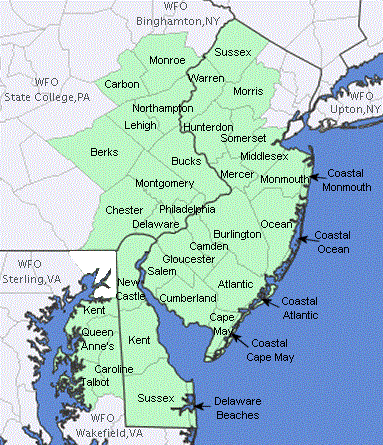
The Philadelphia/Mt.Holly forecast area (if you can't see the image, find here: https://www.weather.gov/phi/ouroffice)

### https://mesonet.agron.iastate.edu/vtec/search.php?mode=list
### https://www.weather.gov/phi/

Also, the shapefiles for the counties came from the United States Census Bureau, with the names and states that counties are in. 

### https://www.census.gov/cgi-bin/geo/shapefiles/index.php?year=2024&layergroup=Counties+%28and+equivalent%29

## Data Cleaning
Luckily, the data was not needed to be cleaned (in terms of NaNs). Data was sorted by year, fixed in terms of formatting (each county broken apart). Also, there are no outliers, as these datapoints are flash flood warnings that were verified by the forecast office itself. Also, the data was put into time order by me, simply by copying and pasting the csv's together. There was most likely an easier method to do this, but the csv formatting changes in 2024, so I just wanted to make sure it was lining up nicely. 

## Data Processing Techniques Used:
For this project, my main ways of processing this data were by text parsing the county names to be read by the code/to be compatible with the county shapefiles, and also grouping flash flood warnings by county and by year. The parsing made it extremely easy for the code to be read, as it was almost impossible for it to be processed in it's raw form. Its raw form looked like "New Castle [DE], Cecil [MD]" for each warning, and needed to be split to be understood in the code. Also, processing it by year and county made it possible to analyze data BY county. Without these two processing methods, the data would have been relatively unusable, and would be impossible to be read. 

## Exploratory Data Analysis

In [3]:
#reading in the flash flood warning data
ffw = pd.read_csv('ffw.csv')
ffw['issue'] = pd.to_datetime(ffw['issue']) #sorting the datetimes 
ffw['year'] = ffw['issue'].dt.year #sorting them by year as well

In [17]:
#the csv file is formatted with the locations like 	Lehigh [PA], Berks [PA], 
#so this separates them to be read by the code

rows = []
for idx, locs in ffw['locations'].items():
    for loc in locs.split(','):
        loc = loc.strip()
        if '[' in loc:
            county, state = loc.split('[')
            rows.append({'ffw_id': idx,'county': county.strip(),'state': state.strip(' ]')})

loc_ffw = pd.DataFrame(rows)

loc_ffw = loc_ffw.merge(ffw[['year']],left_on='ffw_id',right_index=True,how='left')

In [5]:
#counts flash flood warnings for each county for each year
yearly = loc_ffw.groupby(['county','state','year']).size().reset_index(name='ffw_count')

In [6]:
#bringing in the shapefiles for county identification
counties = gpd.read_file('tl_2024_us_county.shp')

state_map = {'42':'PA','34':'NJ','10':'DE','24':'MD'} #how many counties it's loading in per state
counties['state'] = counties['STATEFP'].map(state_map) #associates counties with their states
counties['county'] = counties['NAME'] #county names

counties_phi = counties[counties['state'].notna()]  #eliminates the counties not in the forecasting office region

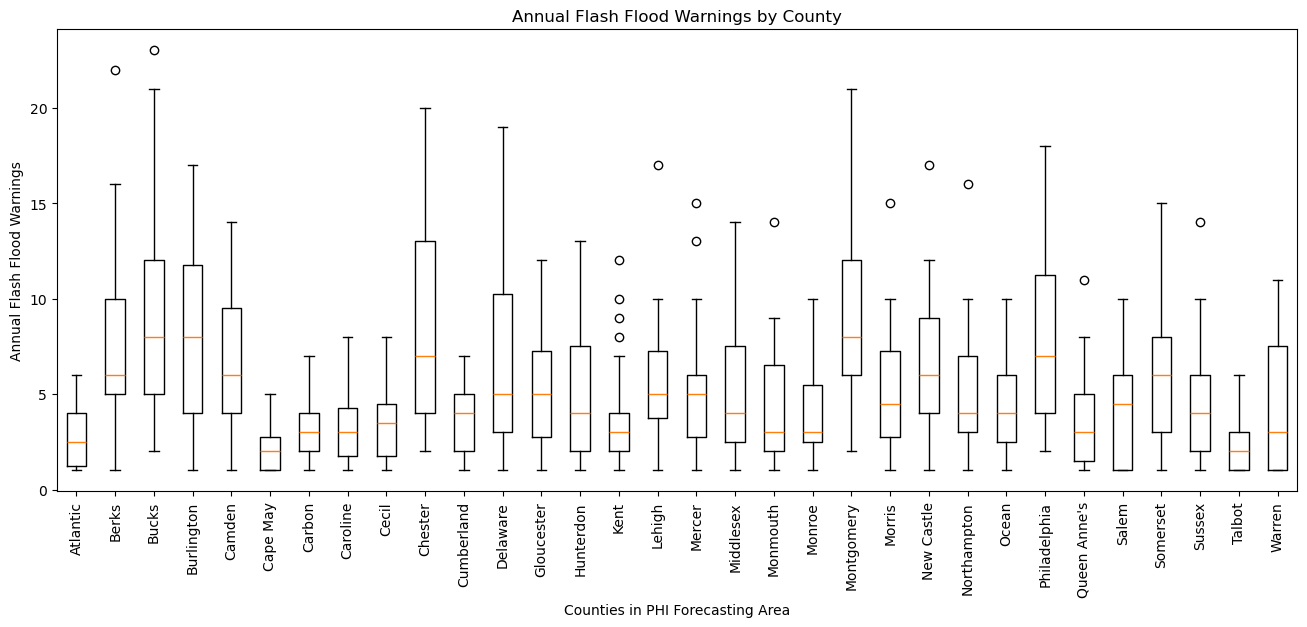

In [7]:
#Boxplot of flash flood warnings by county

counties = yearly['county'].unique()

data = [yearly[yearly['county']==c]['ffw_count'] for c in counties]

plt.figure(figsize=(16,6))
plt.boxplot(data, labels=counties)
plt.xticks(rotation=90)
plt.ylabel('Annual Flash Flood Warnings')
plt.xlabel('Counties in PHI Forecasting Area')
plt.title('Annual Flash Flood Warnings by County')
plt.show()
#The box and whisker plot shows that urban areas have higher medians and greater variability, while rural 
#areas tend to not follow this pattern

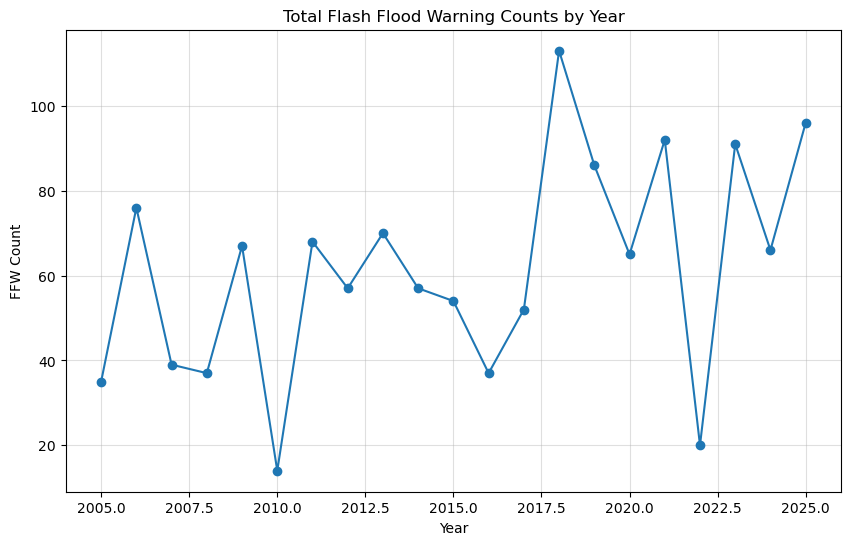

In [8]:
# Total warnings per year across all of the counties

ffw_per_year = ffw.groupby('year').size()

plt.figure(figsize=(10,6))
plt.plot(ffw_per_year.index, ffw_per_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('FFW Count')
plt.title('Total Flash Flood Warning Counts by Year')
plt.grid(alpha=0.4)
plt.show()

#There are a few outliers on this plot (2018 and 2022 are the major ones), but it mostly shows an upward
#trend in the overall flash flood warnings issued in the area 
#2018 was likely higher due to the remnants of Hurricane Michael 

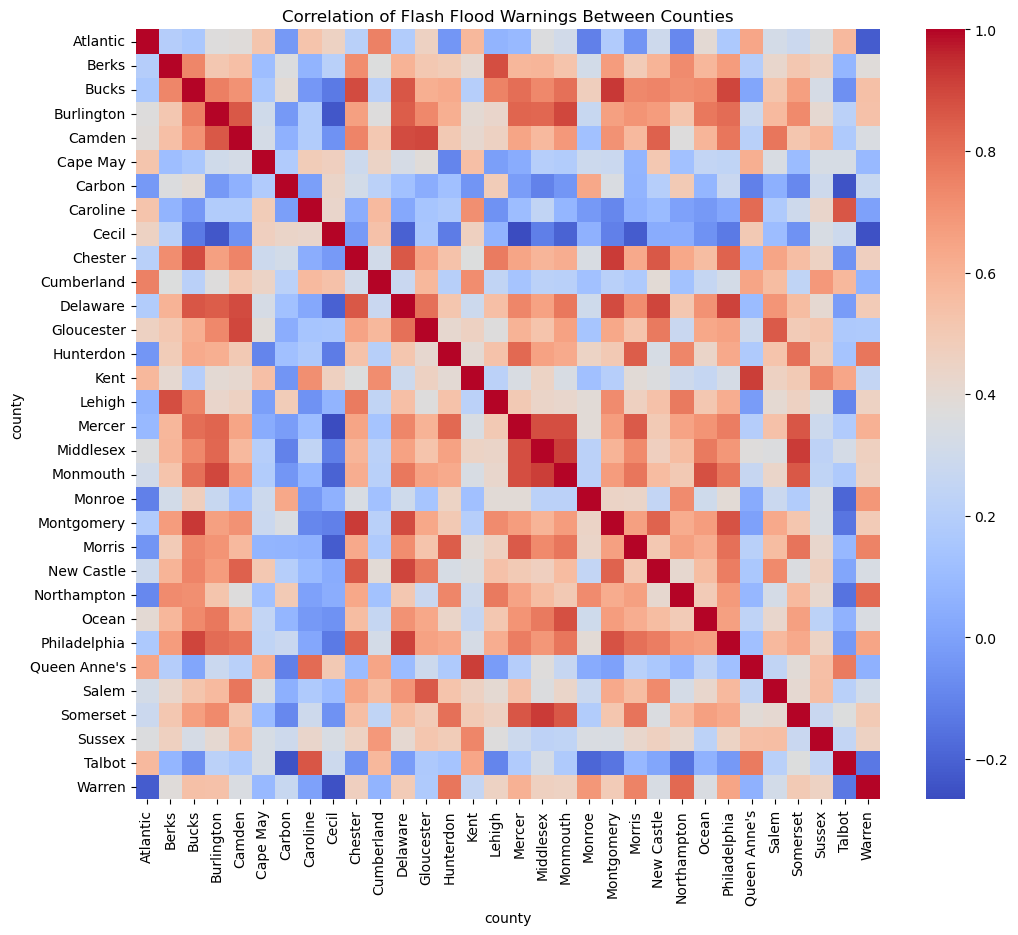

In [9]:
pivot_df = yearly.pivot_table(index='year', columns='county', values='ffw_count')

pivot_df = pivot_df.fillna(0)

corr = pivot_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation of Flash Flood Warnings Between Counties')
plt.show()

#An interesting way to show how counties near each other are more likely to experience clumped flash flooding events
#Key example worthy of mentioning (and easy to see): Middlesex, Monmouth, and Mercer Counties 

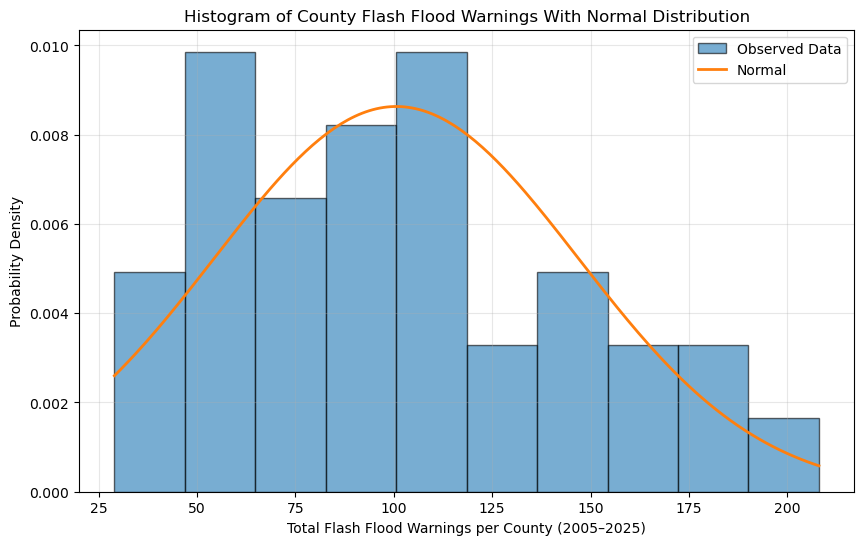

In [13]:
from scipy.stats import norm

county_totals = loc_ffw.groupby(['county','state']).size().reset_index(name='total_ffw')

data = county_totals['total_ffw']

mu = data.mean()
sigma = data.std()

plt.figure(figsize=(10,6))
count_values, bins, _ = plt.hist(data,bins=10,density=True,alpha=0.6,edgecolor='black',label='Observed Data')

x = np.linspace(min(data), max(data), 200)
normal_pdf = norm.pdf(x, mu, sigma)

plt.plot(x, normal_pdf, linewidth=2, label='Normal')

plt.xlabel('Total Flash Flood Warnings per County (2005–2025)')
plt.ylabel('Probability Density')
plt.title('Histogram of County Flash Flood Warnings With Normal Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.show()
#The histogram does not follow a normal distribution perfectly, but it still does a nice job overall.
#The area of 125 flash flood warnings has a low distribution, so it does not fit well into the 
#calculated region of the normal distribution 

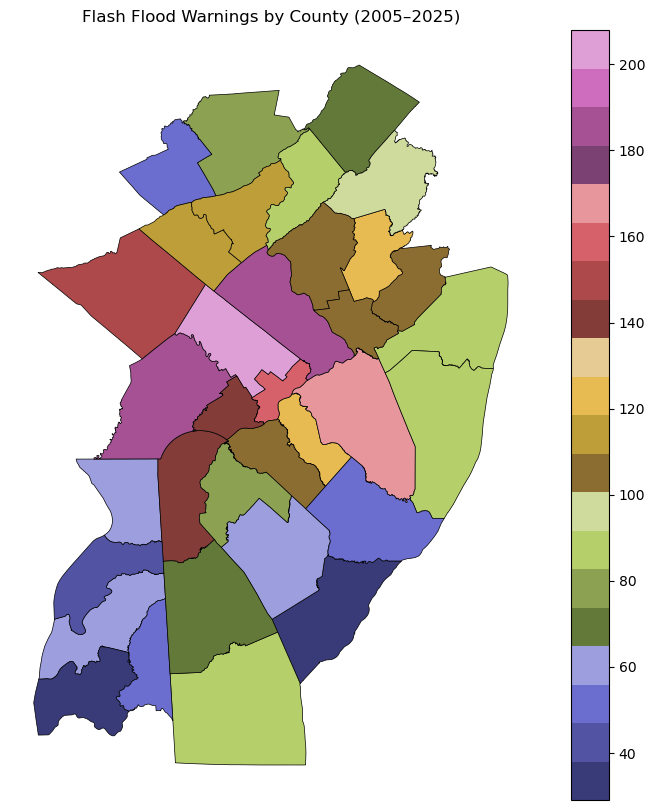

In [11]:
#mapping total flash flood warnings for the 20 year period

#counting flash flood warnings by county
county_totals = (loc_ffw.groupby(['county','state']).size().reset_index(name='total_ffw'))

map_totals = counties_phi.merge(county_totals,on=['county','state'],how='left')

fig, ax = plt.subplots(figsize=(10, 10))

map_totals.plot(column='total_ffw',cmap='tab20b',legend=True,edgecolor='black',linewidth=0.5,ax=ax)

ax.set_title('Flash Flood Warnings by County (2005–2025)')
ax.axis('off')

plt.show()
# A visualization of the heat map of flash flood warnings by county. If you're not familiar with county names, 
# Montgomery county PA has the most flash flood warnings during this time, with Bucks and Chester counties 
# following closely behind. It can be inferred from this map that a lot of the areas with higher amount of flash 
# flood warnings are more likely to be more urbanized. Another thing to note, the flash flood warnings are higher along
# the I-95 corridor (Mercer and Middlesex in New Jersey, Delaware, Philadelphia, and Bucks County in Pennsylvania,
# and New Castle County in Delaware) are all clearly outlined with higher flash flood warning counts.

In [14]:
# Extract month number and month name
ffw['month'] = ffw['issue'].dt.month
ffw['month_name'] = ffw['issue'].dt.month_name()

monthly_counts = ffw.groupby('month_name').size().reindex(['January','February','March','April','May','June','July','August','September','October','November','December'])

monthly_counts = monthly_counts.fillna(0)

monthly_counts

month_name
January        4.0
February       4.0
March          5.0
April         20.0
May           70.0
June         242.0
July         444.0
August       340.0
September    125.0
October       29.0
November       9.0
December       0.0
dtype: float64

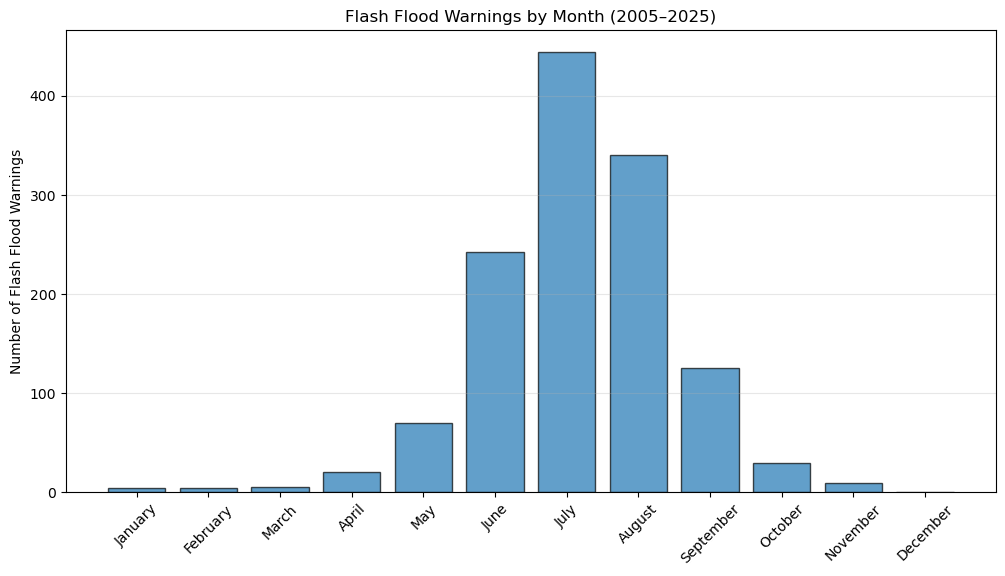

In [13]:
plt.figure(figsize=(12,6))
plt.bar(monthly_counts.index, monthly_counts.values, edgecolor='black', alpha=0.7)

plt.xticks(rotation=45)
plt.ylabel('Number of Flash Flood Warnings')
plt.title('Flash Flood Warnings by Month (2005–2025)')
plt.grid(axis='y', alpha=0.3)

plt.show()

#This plot shows a clear picture of when the most flash flood warnings occur in the PHI/Mt.Holly forecasting
#region. They occur most in July and August

In [15]:
#poisson regression for flash flood warning trends from 2005 to 2025
rows = []

for (county, state), sub in yearly.groupby(['county', 'state']):
    X = sm.add_constant(sub['year'])
    y = sub['ffw_count']

    try:
        model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
        slope = model.params['year']
        pval = model.pvalues['year']
    except:
        slope = np.nan
        pval = np.nan #ignores any counties with no data

    rows.append({'county': county,'state': state,'slope': slope,'pvalue': pval,'percent_change_per_year': (np.exp(slope)-1)*100})

trend_results_df = pd.DataFrame(rows)

In [15]:
#adds significance (if p value is < 0.10 or 0.05)

trend = trend_results_df.copy()
trend['significance'] = pd.cut(trend['pvalue'],bins=[0, 0.05, 0.10, 1],labels=['p < .05', 'p < .10', 'ns'])

trend

,county,state,slope,pvalue,percent_change_per_year,significance
0,Atlantic,NJ,-0.002346,9.266316e-01,-0.234357,ns
1,Berks,PA,0.041947,1.616329e-03,4.283965,p < .05
2,Bucks,PA,0.061194,9.325154e-07,6.310483,p < .05
3,Burlington,NJ,0.074137,1.273893e-07,7.695419,p < .05
4,Camden,NJ,0.052909,1.492054e-03,5.433342,p < .05
5,Cape May,NJ,0.002961,9.285936e-01,0.296502,ns
6,Carbon,PA,-0.029961,2.160857e-01,-2.951657,ns
7,Caroline,MD,-0.026151,2.535326e-01,-2.581209,ns
8,Cecil,MD,0.006193,8.293923e-01,0.621218,ns
9,Chester,PA,0.057168,4.108730e-06,5.883378,p < .05


In [16]:
#county trend results are now correlated with shapefile counties 
mapdf = counties_phi.merge(trend,on=['county','state'],how='inner')     #keeps ONLY PHI counties

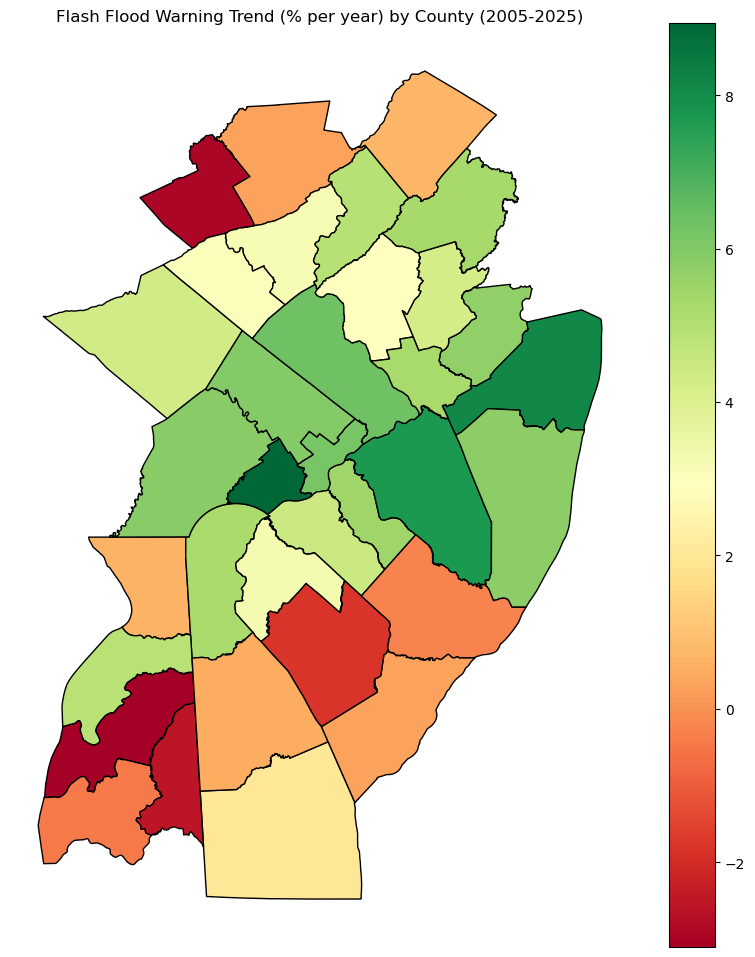

In [17]:
#mapping the percent increase or decrease of flash flood warnings by year

fig, ax = plt.subplots(figsize=(10, 12))

mapdf.plot(column='percent_change_per_year',cmap='RdYlGn',legend=True,edgecolor='black',ax=ax)

ax.set_title('Flash Flood Warning Trend (% per year) by County (2005-2025)')
ax.axis('off')
plt.show()

#This plot shows that most of the counties in the forecast region are experiencing an upward trend in their
#warnings. Delaware county is gaining the most, with an ~8% increase in warnings in the past 20 years.
#Some counties have also seen a decrease, with Queen Anne's seeing ~3% decrease in warnings. 

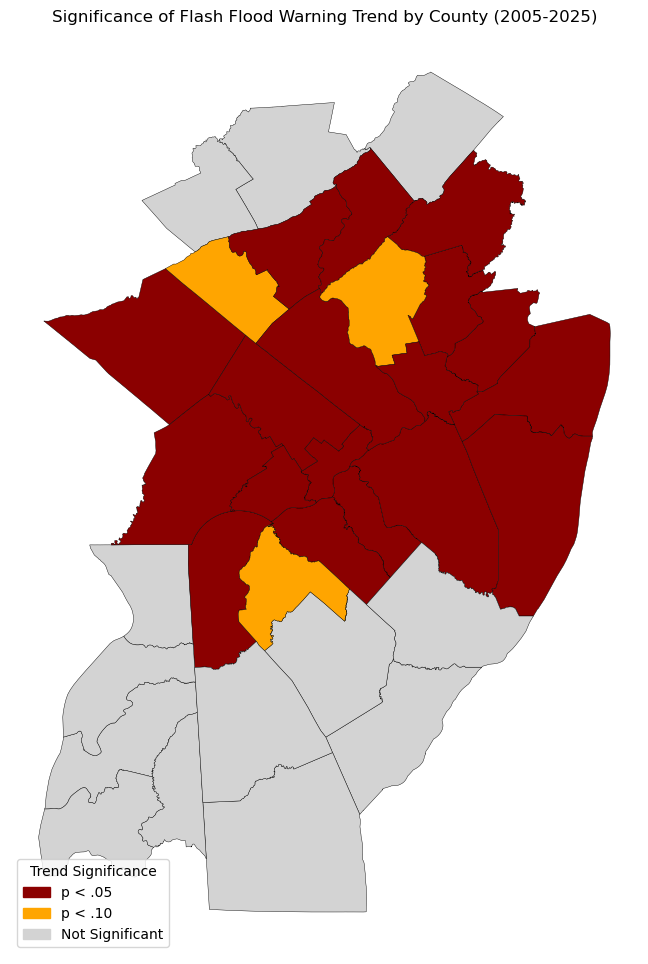

In [18]:
#mapping the p-value (and their significance, if any)

sig_colors = {'p < .05': 'darkred','p < .10': 'orange','ns': 'lightgray'}

mapdf['significance_color'] = mapdf['significance'].map(sig_colors)

fig, ax = plt.subplots(figsize=(10, 12))

mapdf.plot(color=mapdf['significance_color'],linewidth=0.3,edgecolor='black',ax=ax)

ax.set_title('Significance of Flash Flood Warning Trend by County (2005-2025)')
ax.axis('off')

import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='darkred', label='p < .05'),
    mpatches.Patch(color='orange', label='p < .10'),
    mpatches.Patch(color='lightgray', label='Not Significant')
]

ax.legend(handles=legend_patches, title='Trend Significance', loc='lower left')

plt.show()

#This plot is showing that MANY counties in the region are experiencing some form of statistically significant
#change in the number of flash flood warnings in the past 20 years. None of the counties that have decreasing 
#warnings show any statistical significance, it's only counties with increasing warning counts

In [16]:
#NOTE: YOU MAY NEED TO USE PIP INSTALL PYMANNKENDALL FOR THIS PART

#Commented out in case it's needed:
#pip install pymannkendall

import pymannkendall as mk

mk_results = []

for (county, state), sub in yearly.groupby(['county', 'state']):
    series = sub.sort_values('year')['ffw_count']
    
    try:
        result = mk.original_test(series)
        mk_results.append({'county': county,'state': state,'mk_tau': result.Tau,'mk_pvalue': result.p,'mk_trend': result.trend})
    except:
        mk_results.append({'county': county,'state': state,'mk_tau': None,'mk_pvalue': None,'mk_trend': 'insufficient data'})

mann_kendall_df = pd.DataFrame(mk_results)
mann_kendall_df.head()

,county,state,mk_tau,mk_pvalue,mk_trend
0,Atlantic,NJ,-0.039216,0.846070,no trend
1,Berks,PA,0.321637,0.055879,no trend
2,Bucks,PA,0.357143,0.024316,increasing
3,Burlington,NJ,0.594737,0.000253,increasing
4,Camden,NJ,0.391813,0.019752,increasing


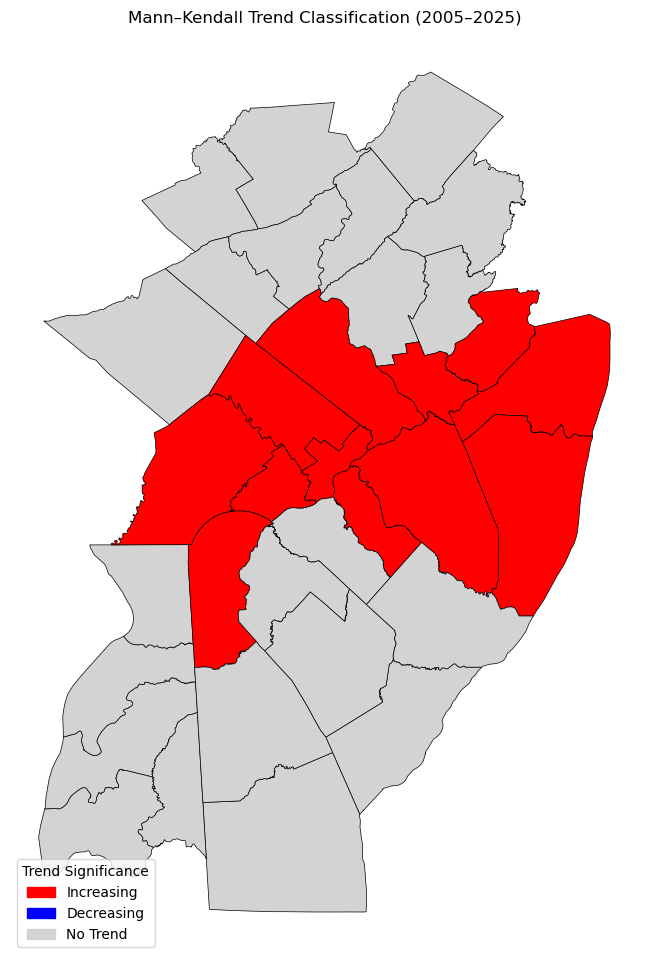

In [20]:
mk_map = counties_phi.merge(mann_kendall_df, on=['county','state'], how='inner')

color_map = {'increasing': 'red','decreasing': 'blue','no trend': 'lightgray'}

mk_map['trend_color'] = mk_map['mk_trend'].map(color_map)
mk_map['trend_color'] = mk_map['trend_color'].fillna('lightgray')

fig, ax = plt.subplots(figsize=(10, 12))
mk_map.plot(color=mk_map['trend_color'], edgecolor='black', linewidth=0.5, ax=ax)
ax.set_title('Mann–Kendall Trend Classification (2005–2025)')
ax.axis('off')

legend_patches = [
    mpatches.Patch(color='red', label='Increasing'),
    mpatches.Patch(color='blue', label='Decreasing'),
    mpatches.Patch(color='lightgray', label='No Trend')
]

ax.legend(handles=legend_patches, title='Trend Significance', loc='lower left')

plt.show()

#The Mann-Kendall trend was used as a method to reinforce what the Poisson method 
#was showing, which was statistical significance in the increase in flash flood 
#warnings in many areas of the forecasting office locations

## Advanced Statistical Analysis Comparison

While there was nothing wrong with the Poisson regression method, using the Mann-Kendall method continues to reinforce the significance of the upward trends of flash flood warnings. The Poisson method assumes that the data takes on a Poisson distribution, so using the Mann-Kendall method was for extra reinforcement, as it analyzes it in a more linear way. Bucks (PA), Burlington (NJ), Camden (NJ), Chester (PA), Delaware (PA), Mercer (NJ), Middlesex (NJ), Monmouth (NJ), Montgomery (PA), New Castle (DE), Ocean (NJ), and Philadelphia (PA) all see an increasing trend in both statistical methods. Counties with p < 0.05 show a strong upward trend in flash flood warnings, with increases ranging from ~3–9% per year. These counties are also the ones that have seen a lot of urban developments (as someone who lives in  Middlesex county, I can confirm the increase in these developments). Also, the  I-95 corridor, I-287, RT 1 and 9, and many other major roadways are all settled into many of these areas, minimizing places for storm water to runoff.

## Conclusion

To conclude, it is evident that there is a rise in flash flood warnings in many counties in the Mt.Holly forecasting office region. These increases are statistically significant, and something that should definitely be taken with caution. Urbanization of many counties in this region are causing an uptick in such events, and the expansion of major roadways (I-95 being the main contributor) is reducing places for stormwater to run off. Counties should begin to look into funding ways to mediate these concerns. 

## Future Work

If I had more time to work on this project, I'd also pull drought data and land cover percentage over time to see if they have any correlation with such an increase in flash flood warnings. Most of my hypothesis of urbanization being the main cause of the increase in flash flood warnings is because I live in the area, and have been a witness to it all. I would also add yearly or monthly precipitation data to see if there has been an increase there as well. This has the opportunity to be a really interesting climate analysis from a place very near and dear to me, so I may have to continue doing personal investigation into this (just for fun). 